# Joint Environment–Schedule Fused-Wall Decoder v1 — fixed beam version

This notebook fixes the crash seen in v0:

```text
KeyError: 28
```

The cause was structural, not cosmetic:

- In the beam search, a wrong predecessor path produces a wrong local wall $F_{\text{node}}$.
- The environment leak was generated from the true wall $F_\*$.
- The previous candidate generator assumed the propagate-bit set for $F_{\text{node}}$ matched the true leak orientation map.
- When $F_{\text{node}}$ created a propagate bit absent from the leak's orientation map, reconstruction requested `O[j]` and crashed.

The fix is the correct VM logic:

$$
F_{\text{node}}\neq F_\*
$$

does not crash. It receives an environment penalty and fills unsupported orientation bits with a neutral prior.

That means wrong paths survive only if their joint score justifies them:

$$
\text{score}=
\text{environment cost}
+
\lambda_F \cdot HW(F_{\text{node}}\oplus F_\*)
+
\lambda_S \cdot R_{\text{schedule}}
$$

This keeps the recursion alive instead of collapsing on a missing key.

## 0. Configuration

In [1]:
# ============================================================
# Config
# ============================================================

RUN_RANDOM_SWEEP = True
RUN_BEAM_DEMO = True

RANDOM_SWEEP_TRIALS = 300
NOISE_LEVELS = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

# Beam defaults. Full 64-round demo should run on normal local hardware.
BEAM_TOPK_PER_ROUND = 8
BEAM_WIDTH = 128
BEAM_NOISE = 0.10
BEAM_MAX_ROUNDS = 64

# Penalty for using a node wall that disagrees with the true/simulated environment wall.
# In real hardware mode this corresponds to wall-consistency with the observed leakage.
LAMBDA_WALL_MISMATCH = 4.0

# Schedule residual penalty. Increase to prune harder once environment candidates are reliable.
LAMBDA_SCHEDULE = 2.0

SEED = 1337

## 1. Imports and SHA-256 primitives

In [2]:
import hashlib
import math
import random
import json
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MASK32 = 0xFFFFFFFF

random.seed(SEED)
np.random.seed(SEED)

H0 = [
    0x6a09e667, 0xbb67ae85, 0x3c6ef372, 0xa54ff53a,
    0x510e527f, 0x9b05688c, 0x1f83d9ab, 0x5be0cd19,
]

K = [
    0x428a2f98,0x71374491,0xb5c0fbcf,0xe9b5dba5,0x3956c25b,0x59f111f1,0x923f82a4,0xab1c5ed5,
    0xd807aa98,0x12835b01,0x243185be,0x550c7dc3,0x72be5d74,0x80deb1fe,0x9bdc06a7,0xc19bf174,
    0xe49b69c1,0xefbe4786,0x0fc19dc6,0x240ca1cc,0x2de92c6f,0x4a7484aa,0x5cb0a9dc,0x76f988da,
    0x983e5152,0xa831c66d,0xb00327c8,0xbf597fc7,0xc6e00bf3,0xd5a79147,0x06ca6351,0x14292967,
    0x27b70a85,0x2e1b2138,0x4d2c6dfc,0x53380d13,0x650a7354,0x766a0abb,0x81c2c92e,0x92722c85,
    0xa2bfe8a1,0xa81a664b,0xc24b8b70,0xc76c51a3,0xd192e819,0xd6990624,0xf40e3585,0x106aa070,
    0x19a4c116,0x1e376c08,0x2748774c,0x34b0bcb5,0x391c0cb3,0x4ed8aa4a,0x5b9cca4f,0x682e6ff3,
    0x748f82ee,0x78a5636f,0x84c87814,0x8cc70208,0x90befffa,0xa4506ceb,0xbef9a3f7,0xc67178f2,
]

def rotr(x, n):
    return ((x >> n) | (x << (32 - n))) & MASK32

def shr(x, n):
    return x >> n

def Ch(x, y, z):
    return (x & y) ^ ((~x & MASK32) & z)

def Maj(x, y, z):
    return (x & y) ^ (x & z) ^ (y & z)

def Sigma0(x):
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def Sigma1(x):
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def sigma0(x):
    return rotr(x, 7) ^ rotr(x, 18) ^ shr(x, 3)

def sigma1(x):
    return rotr(x, 17) ^ rotr(x, 19) ^ shr(x, 10)

def hw32(x):
    return int(x & MASK32).bit_count()

def bits_to_word(bits):
    out = 0
    for j, b in enumerate(bits):
        if b:
            out |= (1 << j)
    return out & MASK32

## 2. SHA-256 one-block trace and exact local reverse closure

In [3]:
def sha256_pad_oneblock(msg: bytes) -> bytes:
    ml = len(msg) * 8
    padded = bytearray(msg)
    padded.append(0x80)
    while (len(padded) % 64) != 56:
        padded.append(0)
    padded += ml.to_bytes(8, "big")
    if len(padded) != 64:
        raise ValueError(f"{len(msg)} bytes requires {len(padded)//64} blocks; this notebook is one-block by default.")
    return bytes(padded)

def make_schedule(block: bytes) -> List[int]:
    W = [int.from_bytes(block[4*i:4*i+4], "big") for i in range(16)]
    for t in range(16, 64):
        W.append((sigma1(W[t-2]) + W[t-7] + sigma0(W[t-15]) + W[t-16]) & MASK32)
    return W

def sha256_trace_oneblock(msg: bytes):
    block = sha256_pad_oneblock(msg)
    W = make_schedule(block)

    a,b,c,d,e,f,g,h = H0
    states = [(a,b,c,d,e,f,g,h)]
    T1s, T2s = [], []

    for r in range(64):
        T1 = (h + Sigma1(e) + Ch(e,f,g) + K[r] + W[r]) & MASK32
        T2 = (Sigma0(a) + Maj(a,b,c)) & MASK32
        h,g,f,e,d,c,b,a = g,f,e,(d + T1) & MASK32,c,b,a,(T1 + T2) & MASK32
        T1s.append(T1)
        T2s.append(T2)
        states.append((a,b,c,d,e,f,g,h))

    internal64 = states[-1]
    digest_words = [(internal64[i] + H0[i]) & MASK32 for i in range(8)]
    digest = b"".join(w.to_bytes(4, "big") for w in digest_words).hex()

    return {
        "msg": msg,
        "block": block,
        "W": W,
        "states": states,
        "T1": T1s,
        "T2": T2s,
        "internal64": internal64,
        "digest": digest,
    }

def restore_internal_from_digest_hex(digest_hex: str) -> Tuple[int, ...]:
    words = [int(digest_hex[i:i+8], 16) for i in range(0, 64, 8)]
    return tuple((words[i] - H0[i]) & MASK32 for i in range(8))

def local_reverse_closure_from_next(x_next: Tuple[int, ...], r: int):
    a1,b1,c1,d1,e1,f1,g1,h1 = x_next
    a,b,c,e,f,g = b1,c1,d1,f1,g1,h1
    T2 = (Sigma0(a) + Maj(a,b,c)) & MASK32
    T1 = (a1 - T2) & MASK32
    d = (e1 - T1) & MASK32
    F = (T1 - Sigma1(e) - Ch(e,f,g) - K[r]) & MASK32
    return {"a":a, "b":b, "c":c, "d":d, "e":e, "f":f, "g":g, "T1":T1, "T2":T2, "F":F}

def reverse_step_with_W(x_next: Tuple[int, ...], W_r: int, r: int):
    p = local_reverse_closure_from_next(x_next, r)
    h = (p["F"] - W_r) & MASK32
    return (p["a"], p["b"], p["c"], p["d"], p["e"], p["f"], p["g"], h)

DOS_HELLO = bytes.fromhex(
    "b409ba0c01cd21b44ccd21"  # DOS print+exit
    "48656c6c6f2124"          # Hello!$
    + "90" * 37               # NOP field to 55 bytes
)

trace = sha256_trace_oneblock(DOS_HELLO)
M = [int.from_bytes(trace["block"][4*i:4*i+4], "big") for i in range(16)]

print("len", len(DOS_HELLO), "digest", trace["digest"])
print("hashlib_match", hashlib.sha256(DOS_HELLO).hexdigest() == trace["digest"])
print("M13,M14,M15:", [f"0x{x:08x}" for x in M[13:16]])
print("x64 restored:", restore_internal_from_digest_hex(trace["digest"]) == trace["internal64"])

ok = True
for r in range(64):
    p = local_reverse_closure_from_next(trace["states"][r+1], r)
    if p["F"] != ((trace["states"][r][7] + trace["W"][r]) & MASK32):
        ok = False
    if reverse_step_with_W(trace["states"][r+1], trace["W"][r], r) != trace["states"][r]:
        ok = False
print("Exact reverse closure validates:", ok)

len 55 digest e079e052b115f0bd7a1f7e4b76b896ecff094435418389aec7c54e26929a3b27
hashlib_match True
M13,M14,M15: ['0x90909080', '0x00000000', '0x000001b8']
x64 restored: True
Exact reverse closure validates: True


## 3. Exact fused-wall theorem: $F+C+O\rightarrow(h,W)$

In [4]:
def adder_trace_operands(h: int, W: int):
    h &= MASK32
    W &= MASK32
    F = (h + W) & MASK32
    c = [0] * 33
    O = {}
    cls = []

    for j in range(32):
        hj = (h >> j) & 1
        wj = (W >> j) & 1
        total = hj + wj + c[j]
        c[j+1] = 1 if total >= 2 else 0

        if hj == 0 and wj == 0:
            cls.append("K")
        elif hj == 1 and wj == 1:
            cls.append("G")
        else:
            cls.append("P")
            O[j] = 0 if (hj, wj) == (1,0) else 1

        assert ((F >> j) & 1) == (total & 1)

    return F, c, O, cls

def reconstruct_from_F_C_O(F: int, c: List[int], O: Dict[int, int]):
    hb = [0] * 32
    wb = [0] * 32

    for j in range(32):
        p = ((F >> j) & 1) ^ c[j]
        if p == 0:
            hb[j] = wb[j] = c[j+1]
        else:
            # v1 fixed: if O is missing, use a neutral default; candidate generator should penalize it.
            o = O.get(j, 0)
            if o == 0:
                hb[j] = 1
                wb[j] = 0
            else:
                hb[j] = 0
                wb[j] = 1

    return bits_to_word(hb), bits_to_word(wb)

ok = True
props = []
for _ in range(1000):
    h = random.getrandbits(32)
    W = random.getrandbits(32)
    F, c, O, cls = adder_trace_operands(h, W)
    hh, WW = reconstruct_from_F_C_O(F, c, O)
    props.append(len(O))
    ok = ok and (hh == h and WW == W)

print("Exact F+C+O theorem passes:", ok)
print("mean propagate bits", np.mean(props), "min/max", min(props), max(props))

Exact F+C+O theorem passes: True
mean propagate bits 15.929 min/max 8 24


## 4. Simulated environment bus and N-best candidates

The important v1 fix is inside `nbest_orientations_from_leak`.

When the node wall $F_{\text{node}}$ differs from the true/simulated leak wall $F_\*$:

1. Add wall mismatch penalty:
   $$
   \lambda_F HW(F_{\text{node}}\oplus F_\*)
   $$
2. Compute the propagate-bit set required by $F_{\text{node}}$ and the observed carries.
3. For missing orientation bits, use a neutral 50/50 prior instead of crashing.

This is what the failed v0 run exposed.

In [5]:
@dataclass
class Leak:
    F_true: int
    carries: List[int]
    measured_orientation: Dict[int, int]
    reliability: float
    true_orientation: Dict[int, int]

@dataclass(order=True)
class Candidate:
    cost: float
    h: int
    W: int
    orientations: dict
    carries: list
    prop_count: int
    wall_mismatch_hw: int
    missing_orientation_bits: int

def make_leak_for_round(h: int, W: int, noise: float, rng=random) -> Leak:
    F, c, O, cls = adder_trace_operands(h, W)
    measured = {}
    for j, o in O.items():
        measured[j] = (1 - o) if rng.random() < noise else o
    reliability = max(0.51, 1.0 - noise)
    return Leak(F, c, measured, reliability, O)

def required_propagate_bits(F: int, c: List[int]) -> List[int]:
    return [j for j in range(32) if (((F >> j) & 1) ^ c[j]) == 1]

def nbest_orientations_from_leak(
    F_node: int,
    leak: Leak,
    topk: int = 8,
    lambda_wall: float = LAMBDA_WALL_MISMATCH,
):
    required = required_propagate_bits(F_node, leak.carries)
    wall_mismatch_hw = hw32(F_node ^ leak.F_true)
    wall_penalty = lambda_wall * wall_mismatch_hw

    p = max(min(leak.reliability, 1 - 1e-12), 1e-12)
    q = 1.0 - p

    opts = []
    missing = 0
    for j in required:
        if j in leak.measured_orientation:
            meas = leak.measured_orientation[j]
            # cost for o=0, cost for o=1
            c0 = -math.log(p if meas == 0 else q)
            c1 = -math.log(q if meas == 0 else p)
        else:
            # This is the v1 fix:
            # F_node requires orientation at a bit absent from the true leak.
            # Use neutral prior plus a small missing-orientation penalty.
            missing += 1
            c0 = -math.log(0.5) + 1.0
            c1 = -math.log(0.5) + 1.0
        opts.append((j, c0, c1))

    base = {}
    base_cost = wall_penalty
    flips = []

    for j, c0, c1 in opts:
        if c0 <= c1:
            base[j] = 0
            base_cost += c0
            flips.append((c1 - c0, j))
        else:
            base[j] = 1
            base_cost += c1
            flips.append((c0 - c1, j))

    flips.sort(key=lambda x: x[0])
    m = min(14, len(flips))
    raw = []
    for mask in range(1 << m):
        O = dict(base)
        cost = base_cost
        for k, (delta, j) in enumerate(flips[:m]):
            if (mask >> k) & 1:
                O[j] = 1 - O[j]
                cost += delta
        raw.append((cost, O))

    raw.sort(key=lambda x: x[0])
    out = []
    for cost, O in raw[:topk]:
        h, W = reconstruct_from_F_C_O(F_node, leak.carries, O)
        out.append(Candidate(
            cost=cost,
            h=h,
            W=W,
            orientations=O,
            carries=leak.carries,
            prop_count=len(required),
            wall_mismatch_hw=wall_mismatch_hw,
            missing_orientation_bits=missing,
        ))
    return out

# Unit test: intentionally use wrong F so required propagate bits differ.
r = 63
true_h = trace["states"][r][7]
true_W = trace["W"][r]
leak = make_leak_for_round(true_h, true_W, noise=0.10)
wrong_F = leak.F_true ^ (1 << 28)  # the previous crash was a missing orientation around a changed bit.
cands = nbest_orientations_from_leak(wrong_F, leak, topk=4)
print("Wrong-F candidate generation works. Candidates:", len(cands))
print("wall_mismatch_hw:", cands[0].wall_mismatch_hw, "missing_orientation_bits:", cands[0].missing_orientation_bits)

Wrong-F candidate generation works. Candidates: 4
wall_mismatch_hw: 1 missing_orientation_bits: 0


## 5. Single-wall noise sweep

,noise,h_bit_acc,W_bit_acc,pair_exact
0,0.00,1.000000,1.000000,1.000000
1,0.05,0.975521,0.975521,0.483333
2,0.10,0.948958,0.948958,0.206667
3,0.15,0.921562,0.921562,0.050000
4,0.20,0.901146,0.901146,0.030000
5,0.25,0.871250,0.871250,0.013333
6,0.30,0.856563,0.856563,0.003333
7,0.35,0.827187,0.827187,0.003333
8,0.40,0.796458,0.796458,0.000000


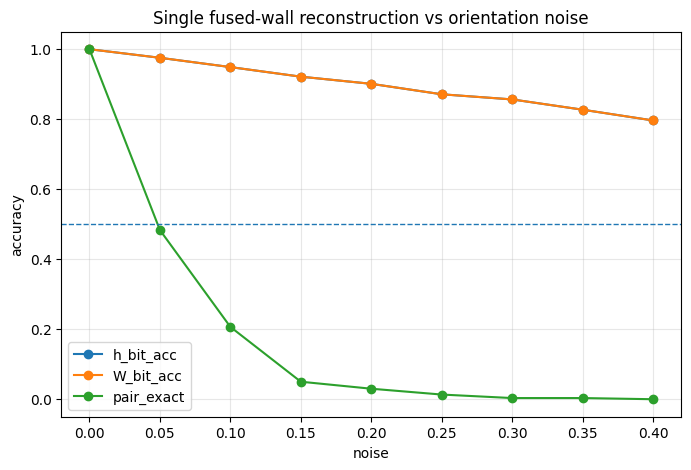

In [6]:
def single_wall_noise_sweep(trials=300, noise_levels=NOISE_LEVELS):
    rows = []
    for noise in noise_levels:
        hc = wc = total = exact = 0
        for _ in range(trials):
            h = random.getrandbits(32)
            W = random.getrandbits(32)
            leak = make_leak_for_round(h, W, noise)
            cand = nbest_orientations_from_leak(leak.F_true, leak, topk=1)[0]
            hc += 32 - hw32(cand.h ^ h)
            wc += 32 - hw32(cand.W ^ W)
            total += 32
            exact += int(cand.h == h and cand.W == W)
        rows.append({
            "noise": noise,
            "h_bit_acc": hc / total,
            "W_bit_acc": wc / total,
            "pair_exact": exact / trials,
        })
    return pd.DataFrame(rows)

if RUN_RANDOM_SWEEP:
    sweep_df = single_wall_noise_sweep(RANDOM_SWEEP_TRIALS)
    display(sweep_df)

    ax = sweep_df.plot(x="noise", y=["h_bit_acc", "W_bit_acc", "pair_exact"], marker="o", figsize=(8,5))
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.set_title("Single fused-wall reconstruction vs orientation noise")
    ax.set_ylabel("accuracy")
    ax.grid(True, alpha=0.3)
    plt.show()

## 6. Schedule legality and delayed-factor beam search

true schedule residual sum 0


,step,round,beam_size,best_score,best_known_word_acc,best_total_hw_error,best_W_bit_acc,true_partial_path_in_beam,closed_schedule_factors_best
54,55,9,128,4264.984747,0.018182,369,0.790341,False,39
55,56,8,128,4350.398728,0.017857,372,0.792411,False,40
56,57,7,128,4433.927298,0.017544,379,0.792215,False,41
57,58,6,128,4521.561228,0.017241,386,0.792026,False,42
58,59,5,128,4610.975209,0.016949,396,0.790254,False,43
59,60,4,128,4709.651665,0.016667,396,0.793750,False,44
60,61,3,128,4798.662661,0.016393,407,0.791496,False,45
61,62,2,128,4860.603445,0.016129,413,0.791835,False,46
62,63,1,128,4941.930522,0.015873,424,0.789683,False,47
63,64,0,128,5022.168929,0.015625,424,0.792969,False,48


decoded rounds 64
word_acc 0.015625
bit_acc 0.79296875
closed_factors 48
score 5022.168929215723


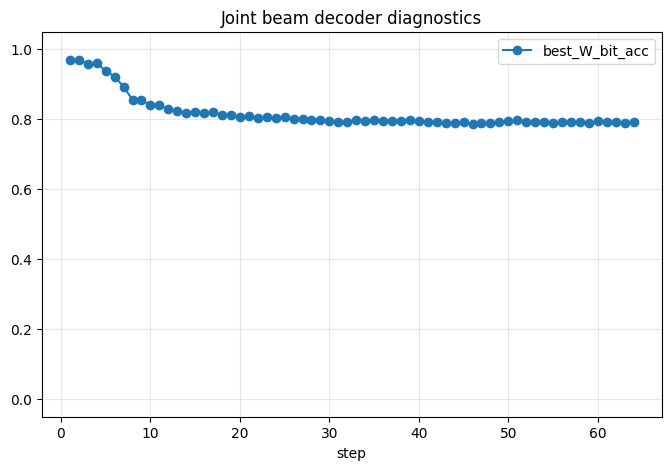

In [7]:
def schedule_pred(Wd: Dict[int, int], t: int) -> int:
    return (sigma1(Wd[t-2]) + Wd[t-7] + sigma0(Wd[t-15]) + Wd[t-16]) & MASK32

def schedule_factor_ready(Wd: Dict[int, int], t: int) -> bool:
    return all(k in Wd for k in (t, t-2, t-7, t-15, t-16))

def schedule_residual_hw(Wd: Dict[int, int], t: int) -> int:
    return hw32(Wd[t] ^ schedule_pred(Wd, t))

Wtrue = {i: trace["W"][i] for i in range(64)}
print("true schedule residual sum", sum(schedule_residual_hw(Wtrue, t) for t in range(16, 64)))

@dataclass
class BeamNode:
    state: Tuple[int, ...]
    W: Dict[int, int]
    score: float
    scored_factors: frozenset
    path: Tuple[Tuple[int, int, float], ...]

def factors_newly_closed(Wd: Dict[int, int], scored):
    return [t for t in range(16, 64) if t not in scored and schedule_factor_ready(Wd, t)]

def make_round_leaks_from_trace(tr, noise):
    return [make_leak_for_round(tr["states"][r][7], tr["W"][r], noise) for r in range(64)]

def joint_beam_decode(
    tr,
    noise=0.10,
    topk=8,
    beam_width=128,
    max_rounds=64,
    lambda_schedule=LAMBDA_SCHEDULE,
    lambda_wall=LAMBDA_WALL_MISMATCH,
):
    x64 = restore_internal_from_digest_hex(tr["digest"])
    leaks = make_round_leaks_from_trace(tr, noise)
    trueW = tr["W"]

    beam = [BeamNode(x64, {}, 0.0, frozenset(), tuple())]
    hist = []

    for step, r in enumerate(list(reversed(range(64)))[:max_rounds], 1):
        new_nodes = []

        for node in beam:
            F_node = local_reverse_closure_from_next(node.state, r)["F"]

            for cand in nbest_orientations_from_leak(F_node, leaks[r], topk=topk, lambda_wall=lambda_wall):
                prev = reverse_step_with_W(node.state, cand.W, r)
                Wd = dict(node.W)
                Wd[r] = cand.W

                score = node.score + cand.cost
                scored = set(node.scored_factors)

                for t in factors_newly_closed(Wd, node.scored_factors):
                    score += lambda_schedule * schedule_residual_hw(Wd, t)
                    scored.add(t)

                new_nodes.append(BeamNode(
                    state=prev,
                    W=Wd,
                    score=score,
                    scored_factors=frozenset(scored),
                    path=node.path + ((r, cand.W, cand.cost),)
                ))

        if not new_nodes:
            raise RuntimeError(f"Beam died at step {step}, round {r}")

        new_nodes.sort(key=lambda n: n.score)
        beam = new_nodes[:beam_width]

        best = beam[0]
        keys = sorted(best.W)
        word_acc = float(np.mean([best.W[k] == trueW[k] for k in keys])) if keys else 0.0
        bit_err = sum(hw32(best.W[k] ^ trueW[k]) for k in keys)
        true_in = any(all(n.W[k] == trueW[k] for k in n.W) for n in beam)

        hist.append({
            "step": step,
            "round": r,
            "beam_size": len(beam),
            "best_score": best.score,
            "best_known_word_acc": word_acc,
            "best_total_hw_error": bit_err,
            "best_W_bit_acc": 1.0 - bit_err / (32 * len(keys)) if keys else 0.0,
            "true_partial_path_in_beam": true_in,
            "closed_schedule_factors_best": len(best.scored_factors),
        })

    return beam, pd.DataFrame(hist)

if RUN_BEAM_DEMO:
    beam, beam_hist = joint_beam_decode(
        trace,
        noise=BEAM_NOISE,
        topk=BEAM_TOPK_PER_ROUND,
        beam_width=BEAM_WIDTH,
        max_rounds=BEAM_MAX_ROUNDS,
        lambda_schedule=LAMBDA_SCHEDULE,
        lambda_wall=LAMBDA_WALL_MISMATCH,
    )

    display(beam_hist.tail(10))

    best = beam[0]
    keys = sorted(best.W)
    trueW = trace["W"]
    word_acc = np.mean([best.W[k] == trueW[k] for k in keys])
    bit_acc = 1.0 - sum(hw32(best.W[k] ^ trueW[k]) for k in keys) / (32 * len(keys))

    print("decoded rounds", len(keys))
    print("word_acc", word_acc)
    print("bit_acc", bit_acc)
    print("closed_factors", len(best.scored_factors))
    print("score", best.score)

    ax = beam_hist.plot(x="step", y=["best_W_bit_acc", "true_partial_path_in_beam"], marker="o", figsize=(8,5))
    ax.set_ylim(-0.05, 1.05)
    ax.set_title("Joint beam decoder diagnostics")
    ax.grid(True, alpha=0.3)
    plt.show()

## 7. Export outputs

In [8]:
results = {
    "digest": trace["digest"],
    "message_len": len(DOS_HELLO),
    "M13_M14_M15": [f"0x{x:08x}" for x in M[13:16]],
    "fix": "wrong-F paths are penalized and missing orientation bits use neutral prior instead of crashing",
}

if "sweep_df" in globals():
    p = "/mnt/data/joint_fused_wall_v1_noise_sweep.csv"
    sweep_df.to_csv(p, index=False)
    results["noise_sweep_csv"] = p

if "beam_hist" in globals():
    p = "/mnt/data/joint_fused_wall_v1_beam_history.csv"
    beam_hist.to_csv(p, index=False)
    results["beam_history_csv"] = p

p = "/mnt/data/joint_fused_wall_v1_summary.json"
with open(p, "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))

{
  "digest": "e079e052b115f0bd7a1f7e4b76b896ecff094435418389aec7c54e26929a3b27",
  "message_len": 55,
  "M13_M14_M15": [
    "0x90909080",
    "0x00000000",
    "0x000001b8"
  ],
  "fix": "wrong-F paths are penalized and missing orientation bits use neutral prior instead of crashing",
  "noise_sweep_csv": "/mnt/data/joint_fused_wall_v1_noise_sweep.csv",
  "beam_history_csv": "/mnt/data/joint_fused_wall_v1_beam_history.csv"
}
